In [1]:
import os, sys

import math
from collections import defaultdict, namedtuple, Counter
import json
import re
import pprint
from enum import Flag, StrEnum, auto # @launchit.collect

from tqdm.notebook import tqdm
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

sys.path.append(os.path.join(project_root_path, 'lib'))
from utils import *
from logging_utils import *

# Setup

In [2]:
LOG = Logging.get()
RNG = np.random.default_rng()
ArrayUtils.init()
xp = ArrayUtils.xp

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/experiment/hdc',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'self_fname': '/home/misha/dev/mine/neurovision/experiment/hdc/embedding.ipynb',
 'self_name': 'embedding',
 'subproject_name': 'hdc',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Сколько квазинезависимых фичей можно вместить в заданную размерность?

In [3]:
EMBEDDING_SIZE = 300

In [4]:
features_count_list = np.logspace(1, 20, num=100, base=2, dtype=int)
cos_sim_metrics = defaultdict(list)
lo = -1 # -1 is a must, otherwise we limit features to be located in a very narrow cone (think of 1/8 sphere for 3D), rendering high cos sims for two random vector even for 10k dims
hi = 1

for features_count in tqdm(features_count_list):
    features = RNG.uniform(lo, hi, size=(features_count, EMBEDDING_SIZE))
    features = ArrayUtils.to_gpu(features)
    features = (features.T / xp.linalg.norm(features, axis=1)).T
    new_feature = RNG.uniform(lo, hi, size=EMBEDDING_SIZE)
    new_feature = ArrayUtils.to_gpu(new_feature)
    new_feature = new_feature / xp.linalg.norm(new_feature)
    cos_sims = xp.abs(features @ new_feature)
    cos_sim_metrics['min'].append(cos_sims.min())
    cos_sim_metrics['max'].append(cos_sims.max())
    cos_sim_metrics['mean'].append(cos_sims.mean())

  0%|          | 0/100 [00:00<?, ?it/s]

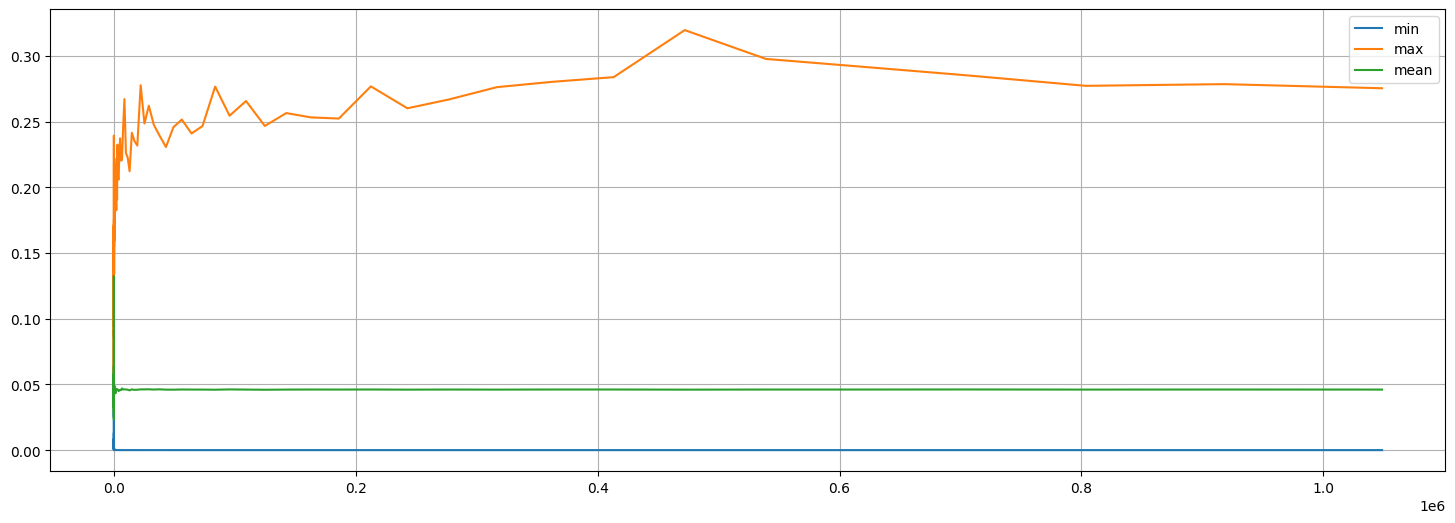

In [5]:
plt.figure(figsize=(18, 6))

for key, values in cos_sim_metrics.items():
    plt.plot(features_count_list, list(map(float, values)), label=key)

plt.grid()
plt.legend();

(np.int64(1048576),
 (array([3.84321e+05, 3.07090e+05, 1.96930e+05, 1.01410e+05, 4.13010e+04,
         1.33610e+04, 3.37000e+03, 6.82000e+02, 9.50000e+01, 1.60000e+01]),
  array([8.77572869e-08, 2.75435549e-02, 5.50870221e-02, 8.26304893e-02,
         1.10173956e-01, 1.37717424e-01, 1.65260891e-01, 1.92804358e-01,
         2.20347825e-01, 2.47891292e-01, 2.75434760e-01]),
  <BarContainer object of 10 artists>))

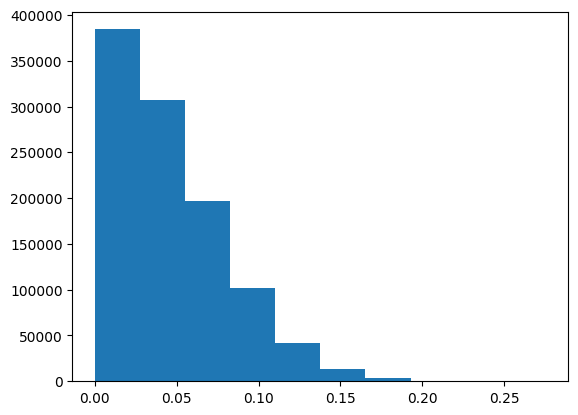

In [6]:
features_count, plt.hist(ArrayUtils.from_gpu(cos_sims))

In [7]:
(cos_sims < 0.05).sum(), (cos_sims < 0.1).sum()

(array(642501), array(961131))

In [8]:
std = cos_sims.std()
(cos_sims < (cos_sims.mean() + std * 3)).sum()

array(1039204)

**ВЫВОДЫ:**
1) для размерности 300 можно спокойно разместить больше миллиона квазинезависимых (низкая степень коррелированности) фичей. 
2) средний уровень коллинеарности (коррелированности) около 5%
3) 64% имеют порог коррелированности <5%
4) 96% имеют порог коррелированности <10%
5) распределения корреляционных коэффициентов похоже на экспоненциальное или полунормальное